# 实验名称
### 研究动机
- 在传统机器学习中，普遍认为模型拟合能力远大于数据集的参数空间规模时，模型会产生严重的过拟合现象。然而随着深度学习的发展，一种普遍的现象却展现出了与之相反的现实：随着大模型的不断发展，大量实验证明复杂的深度学习模型并不会对数据产生过拟合现象，反而展现出名为"涌现"的能力。因此，在阅读相关书籍了解到深度学习目前常用的研究手段为"现象驱动的理论研究"后，作者想通过控制变量实践来研究在基础视觉数据集上究竟是小参数空间配上多信息量数据集的情况还是大参数空间配上少信息量数据集的情况下模型的性能最佳。

### 预实验设计
- 近年来为了解决深度学习模型黑盒的问题，一种研究方式为"先利用人造数据拆解神经网络黑盒的规律和偏好，再利用神经网络的规律和偏好解析真实数据的结构"。从低维人造数据上做数学/统计学实验，观察隐式正则化等现象，再带入更大规模实验。

### 详细信息

- **主题**：探究数据量对不同阶数的模型造成的影响。
- **步骤**：
  1. 基于三角函数生成非线性方程，尝试使用0-100阶多项式去拟合该非线性方程。
  2. 通过梯度下降基于MSE拟合方程，数据点选取50、150作为小数据、大数据对比。选择小中大三个阶段模型，选取的模型测试集MSE小。
  3. 对比因素：核心对比小模型 + 多数据 vs 大模型 + 少数据，以及探究数据量会不会影响模型的收敛点。

In [74]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [75]:
SEED = 42
N_SMALL = 50         # 少信息
N_LARGE = 150        # 多信息
N_TEST = 100
SIGMA = 0.3
D_max, lr, iters = 100, 1e-2, 30000
D_TIERS = [4, 22, 52]  # 小 / 中 / 大

In [76]:
def target_f(x: np.ndarray) -> np.ndarray:
    """目标拟合函数（非多项式，避免与模型同族）。"""
    return np.sin(2 * np.pi * x) + 0.5 * np.cos(5 * np.pi * x)


def generate_train_val(N, seed=SEED):
    """按8：2比例生成训练集、验证集"""
    rng = np.random.default_rng(seed)  # 使用种子超参数创建numpy随机数生成器，确保结果可复现
    x = np.linspace(0.0, 1.0, N)
    y = target_f(x) + rng.normal(0.0, SIGMA, N)
    index = rng.permutation(N)  # 打乱数据集顺序 
    num_train = int(0.8 * N) 
    x_train, y_train = x[index[:num_train]], y[index[:num_train]]
    x_val, y_val = x[index[num_train:]], y[index[num_train:]]
    return x_train, y_train, x_val, y_val

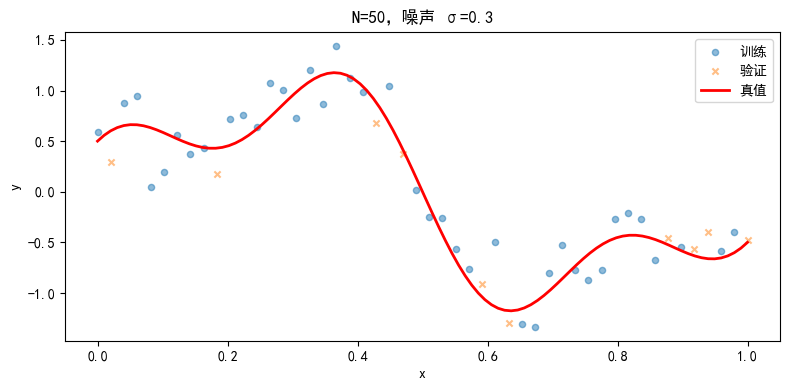

In [77]:
# 生成符合真实函数分布的测试集
x_test = np.linspace(0.0, 1.0, N_TEST)
y_test = target_f(x_test)
x_train, y_train, x_val, y_val = generate_train_val(N_SMALL,SEED)

plt.figure(figsize=(8, 4))
plt.scatter(x_train, y_train, s=20, alpha=0.5, label="训练")
plt.scatter(x_val, y_val, s=20, alpha=0.5, marker="x", label="验证")
plt.plot(x_test, y_test, "r", lw=2, label="真值")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"N={N_SMALL}，噪声 σ={SIGMA}")
plt.legend()
plt.tight_layout()
plt.show()

- 先采用50个数据点训练模型，绘制3个数据集上的误差情况随模型阶数变化的变化情况

In [78]:
# 定义实验所需的计算工具
class GDRegressor:
    def __init__(self,d,lr=1e-2,iters=30000):
        self.d = d
        self.lr = lr
        self.iters = iters
        self.mean = None
        self.std = None
        self.weight = None
        self.num_train = None
    
    def poly_data(self,x):
        return np.vstack([x**k for k in range(self.d+1)]).T
    
    def GD_train(self,x_train,y_train):
        train_data_matrix = self.poly_data(x_train) # 将训练数据变为行为[1,x,x**2,x**3,...],列变为每个样本
        self.mean, self.std = train_data_matrix.mean(axis=0), train_data_matrix.std(axis=0)  # 按列方向统计每列(每个阶数)的均值和标准差，以便进行标准化
        self.std = np.where(self.std < 1e-12, 1.0, self.std)  # 防止第一列导致标准差为1除不尽的情况
        train_data_matrix_normalize = (train_data_matrix - self.mean) / self.std  # 标准化到均值0，标准差为1
        self.weight, num_train = np.zeros(self.d + 1), len(y_train)
        for _ in range(iters):
            self.weight -= self.lr * (2 / num_train) * (train_data_matrix_normalize.T @ (train_data_matrix_normalize @ self.weight - y_train))
    
    def MSE(self,x,y):
        if self.mean is None or self.std is None:
            raise RuntimeError("请先运行 GD_train() 函数!")
        data_matrix_normalize = (self.poly_data(x)-self.mean) / self.std
        return float(np.mean(((data_matrix_normalize @ self.weight) - y) ** 2))

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


N=50  验证最优 D=22  test=0.0917
三档 test MSE: {4: '0.1507', 22: '0.0917', 52: '0.0845'}


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


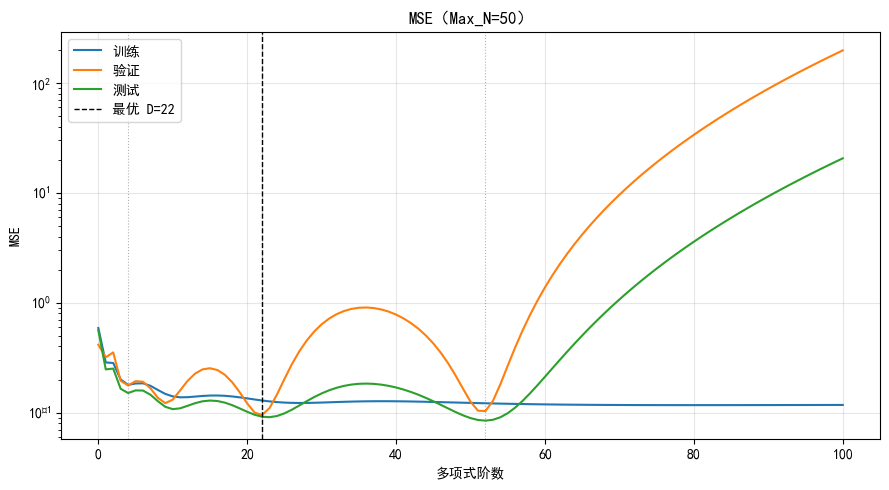

In [79]:
order_list = list[int](range(D_max + 1))  # 构建多项式阶数列表
train_50_mse, val_50_mse, test_50_mse = [], [], [] 

for d in order_list: 
    model = GDRegressor(d=d, lr=lr, iters=iters)
    model.GD_train(x_train, y_train)
    train_50_mse.append(model.MSE(x_train, y_train))
    val_50_mse.append(model.MSE(x_val, y_val))
    test_50_mse.append(model.MSE(x_test, y_test))

best = int(np.argmin(val_50_mse)) # 基于验证集进行最优选模
print(f"N={N_SMALL}  验证最优 D={best}  test={test_50_mse[best]:.4f}")
print("三档 test MSE:", {d: f"{test_50_mse[d]:.4f}" for d in D_TIERS})

plt.figure(figsize=(9, 5))
plt.plot(order_list, train_50_mse, label="训练")
plt.plot(order_list, val_50_mse, label="验证")
plt.plot(order_list, test_50_mse, label="测试")
for d in D_TIERS:
    plt.axvline(d, color="gray", ls=":", lw=0.8, alpha=0.6)
plt.axvline(best, color="k", ls="--", lw=1, label=f"最优 D={best}")
plt.xlabel("多项式阶数")
plt.ylabel("MSE")
plt.yscale("log")
plt.title(f"MSE（Max_N={N_SMALL}）")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- 接下来进行150数据点的不同阶数多项式训练

In [80]:
# N=150：与 N=50 相同方式扫阶，存 train / val / test 三条列表
x_train_150, y_train_150, x_val_150, y_val_150 = generate_train_val(N_LARGE, seed=SEED)

train_150_mse, val_150_mse, test_150_mse = [], [], []
for d in order_list:
    model = GDRegressor(d=d, lr=lr, iters=iters)
    model.GD_train(x_train_150, y_train_150)
    train_150_mse.append(model.MSE(x_train_150, y_train_150))
    val_150_mse.append(model.MSE(x_val_150, y_val_150))
    test_150_mse.append(model.MSE(x_test, y_test))

print(f"N={N_LARGE} 完成，共 {len(test_150_mse)} 个阶数")
print("三档 test MSE:", {d: f"{test_150_mse[d]:.4f}" for d in D_TIERS})

N=150 完成，共 101 个阶数
三档 test MSE: {4: '0.1490', 22: '0.0870', 52: '0.0833'}


   D        N=50       N=150           Δ
   4      0.1507      0.1490     -0.0017
  22      0.0917      0.0870     -0.0047
  52      0.0845      0.0833     -0.0012


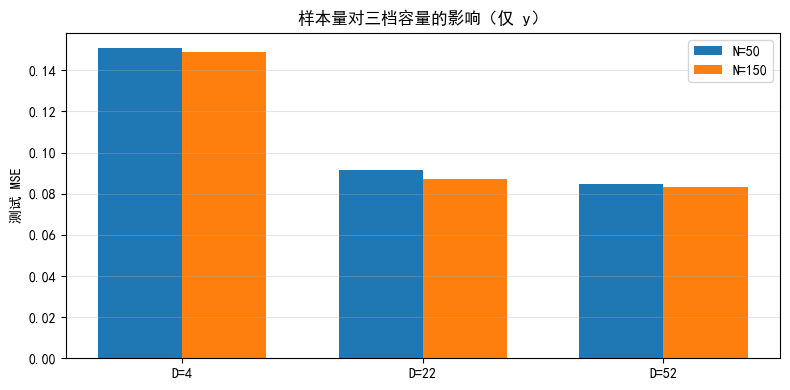

In [84]:
# 直接从列表按下标取三档（d 即阶数，与 order_list 下标一致）
print(f"{'D':>4}  {'N=50':>10}  {'N=150':>10}  {'Δ':>10}")
for d in D_TIERS:
    t50, t150 = test_50_mse[d], test_150_mse[d]
    print(f"{d:4d}  {t50:10.4f}  {t150:10.4f}  {t150 - t50:+10.4f}")

x = np.arange(len(D_TIERS))
bw = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - bw / 2, [test_50_mse[d] for d in D_TIERS], bw, label=f"N={N_SMALL}")
ax.bar(x + bw / 2, [test_150_mse[d] for d in D_TIERS], bw, label=f"N={N_LARGE}")
ax.set_xticks(x, [f"D={d}" for d in D_TIERS])
ax.set_ylabel("测试 MSE")
ax.set_title("样本量对三档容量的影响（仅 y）")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

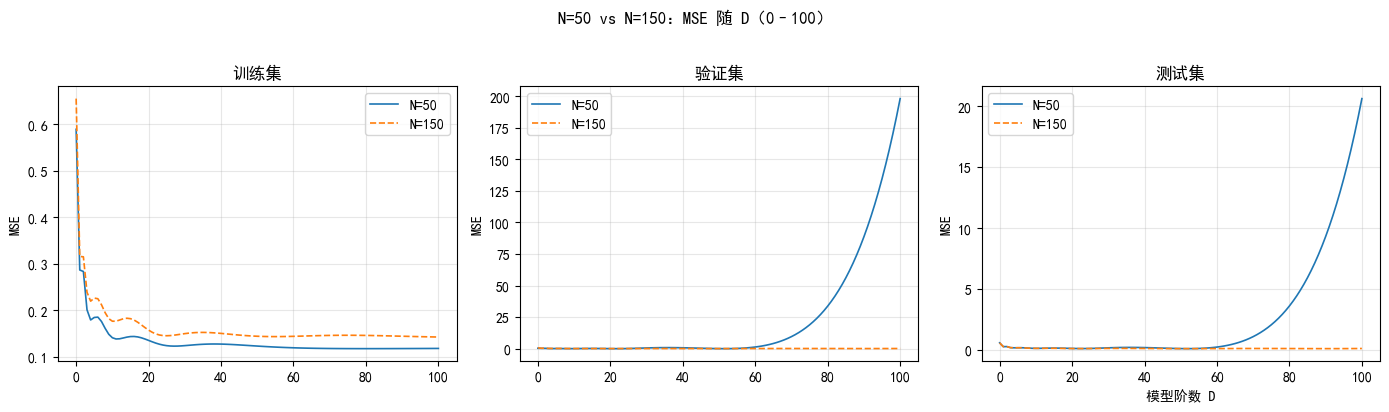

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, title, tr50, tr150 in zip(
    axes,
    ["训练集", "验证集", "测试集"],
    [train_50_mse, val_50_mse, test_50_mse],
    [train_150_mse, val_150_mse, test_150_mse],
):
    ax.plot(order_list, tr50, "-", lw=1.2, label=f"N={N_SMALL}")
    ax.plot(order_list, tr150, "--", lw=1.2, label=f"N={N_LARGE}")
    ax.set_ylabel("MSE")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("模型阶数 D")
fig.suptitle("N=50 vs N=150：MSE 随 D（0–100）", y=1.02)
plt.tight_layout()
plt.show()
plt.show()

- 分析：值得一提的是，由于“域”问题，一旦我们将测试集范围超出0-1，越高阶数的模型越容易引发域外损失爆炸现象。但是我们经过对比试验发现数据点到约100以上时却没有发生测试集损失爆炸现象（测试集范围x轴0-1.1）。如上图所示，数据量大的时候能够很好的约束高复杂度模型。在此预实验上，小模型配上大数据没有明显提升，大模型无论是在小数据上还是大数据上都遥遥领先小模型，因此预实验中数据量对于模型的泛化能力帮助更大。且推测深度学习的模型复杂性正如N=150曲线所示，尽管模型复杂度一直增加但始终没有发生过拟合现象。

- 结论：在本次预实验中，我们通过构建一个三角函数非线性方程，采用0-100阶段的多项式对齐进行拟合。通过控制数据量的多少来观察模型的测试集表现。实验证明：在人造数据集上小数据量会在高阶多项式中表现出剧烈震荡状态，而随着更多数据量的加入，相当于给模型做了一种约束，缓解高阶多项式下的震荡情况。

- 推论：在CIFAR-10与CIFAR-100数据集上，数据样本量往往比模型复杂度更重要，将ResNet-152结合所有训练样本的灰度图在性能上相比AlexNet结合所有训练数据彩色图要低；而如果将60000张训练集变为灰度图的性能降低程度相比将60000张图像降低为20000张低(样本量>样本信息量>模型复杂度(小模型也有一定规模))。现代深度学习模型正是在大数据量+大模型容量的共同约束下，表现出如本预实验中的100阶段多项式被150个样本点很好的约束的效果。

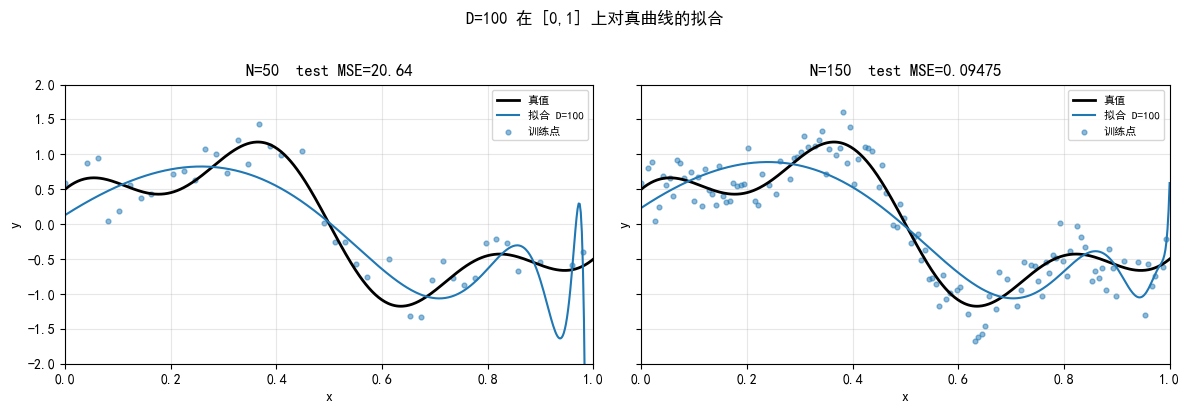

In [93]:
x_line = np.linspace(0.0, 1.0, 500)
y_true = target_f(x_line)

def predict(model, x):
    Q = (model.poly_data(x) - model.mean) / model.std
    return Q @ model.weight

# 两种样本量各训一个 D=100 模型
configs = [
    (N_SMALL, x_train, y_train, f"N={N_SMALL}"),
    (N_LARGE, None, None, f"N={N_LARGE}"),
]
x150_tr, y150_tr, _, _ = generate_train_val(N_LARGE, seed=SEED)
configs[1] = (N_LARGE, x150_tr, y150_tr, f"N={N_LARGE}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (N, xtr, ytr, title) in zip(axes, configs):
    m = GDRegressor(d=D_max, lr=lr, iters=iters)
    m.GD_train(xtr, ytr)
    y_hat = predict(m, x_line)
    te = m.MSE(x_test, y_test)

    ax.plot(x_line, y_true, "k", lw=2, label="真值")
    ax.plot(x_line, y_hat, lw=1.5, label=f"拟合 D={D_max}")
    ax.scatter(xtr, ytr, s=12, alpha=0.5, label="训练点")
    ax.set_xlim(0, 1)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}  test MSE={te:.4g}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"D={D_max} 在 [0,1] 上对真曲线的拟合", y=1.02)
plt.tight_layout()
plt.show()